MAE = 42.79409467959994
RMSE = 53.853445836765914
R2 = 0.4526027629719197


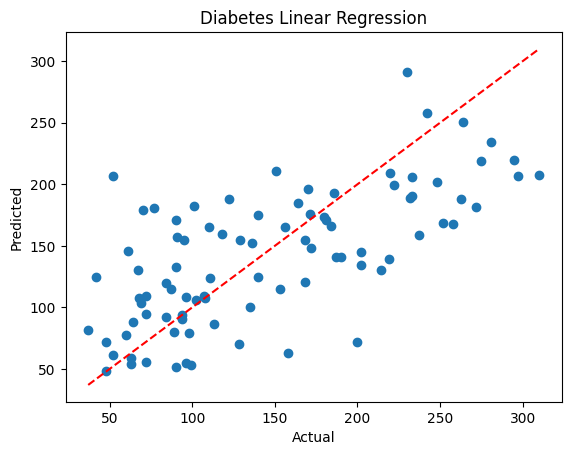

In [6]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

diabetes = load_diabetes()

X = diabetes.data
y = diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE =", mae)
print("RMSE =", rmse)
print("R2 =", r2)

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Diabetes Linear Regression")
plt.show()

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
for k in [3, 7, 15,20]:

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    print(f"\nk = {k}")
    print("Accuracy =", acc)

    print(classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    ))


k = 3
Accuracy = 0.9210526315789473
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.81      1.00      0.90        13
   virginica       1.00      0.77      0.87        13

    accuracy                           0.92        38
   macro avg       0.94      0.92      0.92        38
weighted avg       0.94      0.92      0.92        38


k = 7
Accuracy = 0.9473684210526315
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38


k = 15
Accuracy = 0.9736842105263158
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor     

In [ ]:
#k=15 gives the highest accuracy....
#smaller value of k results in overfitting meaning memorizing the training dats so muhc that can perform poorly in while evaluting 
#the test data as no understanding was gaianed wile training.(big difference in accuracy is observed, training accuracy>>testing accuracy)
# larger value of k results in underfitting  meaning it did not even learn training data properly(training and testing accuries both are low)

NameError: name 'n' is not defined

In [15]:
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             mean_absolute_error, r2_score)
# == STAGE 1: Build and clean dataset ===============================
np.random.seed(7)
n = 120
raw = pd.DataFrame({
    'study_hours' : np.random.uniform(1, 10, n),
    'attendance'  : np.random.randint(50, 100, n),
    'prev_grade'  : np.random.choice(['A','B','C','D'], n),
    'final_score' : np.random.uniform(30, 100, n),
})
# Inject noise
raw.loc[5,  'final_score'] = np.nan
raw.loc[18, 'study_hours'] = np.nan
print('=== RAW DATA ===')
print(raw.isnull().sum())
# == STAGE 2: Clean ================================================
df = raw.copy()
df['final_score']=df['final_score'].fillna(df['final_score'].median())
df['study_hours']=df['study_hours'].fillna(df['study_hours'].median())

# == STAGE 3: Feature engineering ==================================

# Encode prev_grade as numeric (ordinal)
grade_map = {'A':4, 'B':3, 'C':2, 'D':1}
df['grade_num'] = df['prev_grade'].map(grade_map)

# Add new feature: sleep_hours
df['sleep_hours'] = np.random.uniform(4, 9, n)

# Create binary target
df['passed'] = (df['final_score'] >= 50).astype(int)

print(f'Pass rate: {df["passed"].mean()*100:.1f}%')


# ================================================================
# MODEL 1 : WITHOUT sleep_hours
# ================================================================

features1 = ['study_hours', 'attendance', 'grade_num']

X1 = df[features1].values
y = df['passed'].values

X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler1 = StandardScaler()

X1_train = scaler1.fit_transform(X1_train)
X1_test  = scaler1.transform(X1_test)

knn1 = KNeighborsClassifier(n_neighbors=7)

knn1.fit(X1_train, y_train)

y_pred1 = knn1.predict(X1_test)

acc_before = accuracy_score(y_test, y_pred1)


# ================================================================
# MODEL 2 : WITH sleep_hours
# ================================================================

features2 = ['study_hours', 'attendance',
             'grade_num', 'sleep_hours']

X2 = df[features2].values

X2_train, X2_test, y_train, y_test = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler2 = StandardScaler()

X2_train = scaler2.fit_transform(X2_train)
X2_test  = scaler2.transform(X2_test)

knn2 = KNeighborsClassifier(n_neighbors=7)

knn2.fit(X2_train, y_train)

y_pred2 = knn2.predict(X2_test)

acc_after = accuracy_score(y_test, y_pred2)


# ================================================================
# COMPARISON
# ================================================================

print()
print("=== ACCURACY COMPARISON ===")

print(f"Without sleep_hours : {acc_before*100:.1f}%")

print(f"With sleep_hours    : {acc_after*100:.1f}%")

if acc_after > acc_before:
    print("Adding sleep_hours improved accuracy.")

elif acc_after < acc_before:
    print("Adding sleep_hours reduced accuracy.")

else:
    print("Adding sleep_hours made no difference.")

=== RAW DATA ===
study_hours    1
attendance     0
prev_grade     0
final_score    1
dtype: int64
Pass rate: 65.8%

=== ACCURACY COMPARISON ===
Without sleep_hours : 58.3%
With sleep_hours    : 66.7%
Adding sleep_hours improved accuracy.


In [ ]:
import joblib

joblib.dump(knn, "iris_knn.pkl")
joblib.dump(scaler, "iris_scaler.pkl")

print("Model and scaler saved successfully!")


Model and scaler saved successfully!


In [17]:
loaded_model = joblib.load("iris_knn.pkl")
loaded_scaler = joblib.load("iris_scaler.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
new_data = [
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.9, 4.5, 1.5],
    [7.2, 3.0, 5.8, 1.8]
]
#sepal length
#sepal width
#petal length
#petal width

In [21]:
new_data_scaled = loaded_scaler.transform(new_data)
predictions = loaded_model.predict(new_data_scaled)

print(predictions)
from sklearn.datasets import load_iris

iris = load_iris()

class_names = iris.target_names

for i, pred in enumerate(predictions):
    print(f"Flower {i+1}: {class_names[pred]}")

[0 1 2]
Flower 1: setosa
Flower 2: versicolor
Flower 3: virginica


In [ ]:
#pkl files=Pickle files
#stores files

=== RAW DATA ===
study_hours    1
attendance     0
prev_grade     0
final_score    1
dtype: int64
Pass rate: 65.8%

=== MODEL RESULTS ===
Accuracy: 75.0%

              precision    recall  f1-score   support

        Fail       0.62      0.62      0.62         8
        Pass       0.81      0.81      0.81        16

    accuracy                           0.75        24
   macro avg       0.72      0.72      0.72        24
weighted avg       0.75      0.75      0.75        24



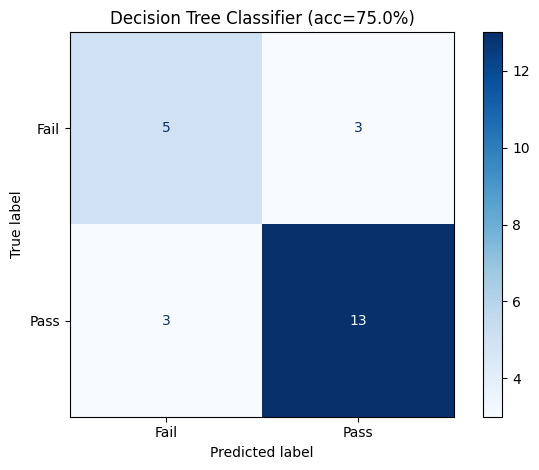

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# == STAGE 1: Build and clean dataset =============================

np.random.seed(7)
n = 120

raw = pd.DataFrame({
    'study_hours': np.random.uniform(1, 10, n),
    'attendance': np.random.randint(50, 100, n),
    'prev_grade': np.random.choice(['A', 'B', 'C', 'D'], n),
    'final_score': np.random.uniform(30, 100, n)
})

# Inject missing values
raw.loc[5, 'final_score'] = np.nan
raw.loc[18, 'study_hours'] = np.nan

print("=== RAW DATA ===")
print(raw.isnull().sum())

# == STAGE 2: Clean ==============================================

df = raw.copy()

df['final_score'] = df['final_score'].fillna(df['final_score'].median())
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].median())

# == STAGE 3: Feature Engineering ================================

grade_map = {
    'A': 4,
    'B': 3,
    'C': 2,
    'D': 1
}

df['grade_num'] = df['prev_grade'].map(grade_map)

# Binary target
df['passed'] = (df['final_score'] >= 50).astype(int)

print(f'Pass rate: {df["passed"].mean()*100:.1f}%')

# == STAGE 4: Prepare X and y ====================================

features = ['study_hours', 'attendance', 'grade_num']

X = df[features]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# == STAGE 5: Train Decision Tree ================================

tree = DecisionTreeClassifier(random_state=42)

tree.fit(X_train, y_train)

# == STAGE 6: Predict ============================================

y_pred = tree.predict(X_test)

# == STAGE 7: Evaluate ===========================================

acc = accuracy_score(y_test, y_pred)

print()
print("=== MODEL RESULTS ===")
print(f"Accuracy: {acc*100:.1f}%")

print()
print(classification_report(
    y_test,
    y_pred,
    target_names=['Fail', 'Pass']
))

# == STAGE 8: Plot Confusion Matrix ==============================

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Fail', 'Pass'],
    cmap='Blues'
)

plt.title(f'Decision Tree Classifier (acc={acc*100:.1f}%)')
plt.tight_layout()
plt.savefig('decision_tree_cm.png', dpi=150)
plt.show()

In [ ]:
#knn needs scaling, as they use distance so large-valued features could dominate
#decision tree does not require scaling they dont measure distances, they compare